distribution-based 

In [21]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
centroid = pd.read_parquet(
    "../data/processed/04_centroid_drift/centroid_drift_wpz_neighbors.parquet"
)

gaussian = pd.read_parquet(
    "../data/processed/06_gaussian_distribution_drift/gaussian_w2_drift_wpz_neighbors.parquet"
)

print(centroid.shape)
print(gaussian.shape)

print(centroid.groupby("modality")["cosine_distance"].describe())
print(gaussian.groupby("modality")["w2_distance"].describe())
print(gaussian.groupby("modality")[["mean_component", "std_component"]].mean())

(18268, 11)
(14913, 13)
                count      mean       std       min       25%       50%  \
modality                                                                  
essentia       3076.0  0.048244  0.062655  0.000377  0.013230  0.028557   
lyrics_tf_idf  3076.0  0.131162  0.083778  0.000202  0.072224  0.117742   
mfcc           3076.0  0.048986  0.064387  0.000040  0.010890  0.026090   
musicnn        3076.0  0.019336  0.034674  0.000069  0.002882  0.007909   
vgg19          2888.0  0.098772  0.091577  0.000118  0.038222  0.072895   
word2vec       3076.0  0.057076  0.071246  0.000013  0.012173  0.033075   

                    75%       max  
modality                           
essentia       0.058497  1.089618  
lyrics_tf_idf  0.171640  0.555454  
mfcc           0.060595  0.586259  
musicnn        0.020019  0.405253  
vgg19          0.129504  0.839553  
word2vec       0.074279  0.708198  
                count       mean       std       min       25%        50%  \
modality  

In [3]:
gaussian_modality_summary = (
    gaussian
    .groupby("modality")["w2_distance"]
    .agg(
        n_comparisons="count",
        mean_w2="mean",
        median_w2="median",
        std_w2="std",
        min_w2="min",
        max_w2="max"
    )
    .sort_values("median_w2", ascending=False)
    .reset_index()
)

gaussian_modality_summary

,modality,n_comparisons,mean_w2,median_w2,std_w2,min_w2,max_w2
0,lyrics_tf_idf,2515,11.962482,11.829493,4.202436,0.274167,28.272071
1,vgg19,2338,12.444504,11.502626,6.170147,0.857643,50.620984
2,essentia,2515,6.084773,4.942005,5.213534,0.834218,111.797121
3,word2vec,2515,1.569341,1.421017,0.828246,0.158907,7.094866
4,mfcc,2515,1.399564,1.106506,1.107577,0.099407,15.045848
5,musicnn,2515,0.989933,0.796258,0.733379,0.080704,8.989456


In [4]:
gaussian_component_summary = (
    gaussian
    .groupby("modality")[["w2_distance", "mean_component", "std_component"]]
    .agg(["count", "mean", "median", "std"])
)

gaussian_component_summary

w2_distance                                 mean_component  \
                    count       mean     median       std          count   
modality                                                                   
essentia             2515   6.084773   4.942005  5.213534           2515   
lyrics_tf_idf        2515  11.962482  11.829493  4.202436           2515   
mfcc                 2515   1.399564   1.106506  1.107577           2515   
musicnn              2515   0.989933   0.796258  0.733379           2515   
vgg19                2338  12.444504  11.502626  6.170147           2338   
word2vec             2515   1.569341   1.421017  0.828246           2515   

                                            std_component             \
                   mean    median       std         count       mean   
modality                                                               
essentia       2.243250  2.015251  1.270037          2515   5.568252   
lyrics_tf_idf  2.095477  2.015680  1.004044          2515  11.769251   
mfcc           0.700248  0.612343  0.405461          2515   1.179446   
musicnn        0.481418  0.402974  0.336137          2515   0.840693   
vgg19          7.515537  6.771687  4.092967          2338   9.845242   
word2vec       1.201137  1.097865  0.644722          2515   0.985943   

                                    
                  median       std  
modality                            
essentia        4.412625  5.153174  
lyrics_tf_idf  11.663931  4.104525  
mfcc            0.877180  1.067566  
musicnn         0.644154  0.682871  
vgg19           9.159245  4.772058  
word2vec        0.872289  0.564236

In [5]:
centroid_summary = (
    centroid
    .groupby("modality")["cosine_distance"]
    .agg(
        centroid_median="median",
        centroid_mean="mean",
        centroid_count="count"
    )
    .reset_index()
)

gaussian_summary = (
    gaussian
    .groupby("modality")["w2_distance"]
    .agg(
        gaussian_median="median",
        gaussian_mean="mean",
        gaussian_count="count"
    )
    .reset_index()
)

comparison = centroid_summary.merge(
    gaussian_summary,
    on="modality",
    how="inner"
)

comparison["centroid_rank"] = comparison["centroid_median"].rank(
    ascending=False,
    method="min"
)

comparison["gaussian_rank"] = comparison["gaussian_median"].rank(
    ascending=False,
    method="min"
)

comparison = comparison.sort_values("centroid_rank")

comparison

,modality,centroid_median,centroid_mean,centroid_count,gaussian_median,gaussian_mean,gaussian_count,centroid_rank,gaussian_rank
1,lyrics_tf_idf,0.117742,0.131162,3076,11.829493,11.962482,2515,1.0,1.0
4,vgg19,0.072895,0.098772,2888,11.502626,12.444504,2338,2.0,2.0
5,word2vec,0.033075,0.057076,3076,1.421017,1.569341,2515,3.0,4.0
0,essentia,0.028557,0.048244,3076,4.942005,6.084773,2515,4.0,3.0
2,mfcc,0.026090,0.048986,3076,1.106506,1.399564,2515,5.0,5.0
3,musicnn,0.007909,0.019336,3076,0.796258,0.989933,2515,6.0,6.0


In [15]:
gaussian_w2_drift_wpz_neighbors_path = "../data/processed/06_gaussian_distribution_drift/gaussian_w2_drift_wpz_neighbors.parquet"

In [16]:
gaussian = pd.read_parquet(gaussian_w2_drift_wpz_neighbors_path)

In [17]:
gaussian

,modality,genre,window_start,window_end,next_window_start,next_window_end,window_gap,n_tracks_t,n_tracks_t1,w2_distance,w2_squared,mean_component,std_component
0,essentia,alternative metal,1997,2001,1998,2002,1,34,51,13.582441,184.482690,3.446403,13.137922
1,essentia,alternative metal,1998,2002,1999,2003,1,51,44,6.074669,36.901601,2.795829,5.393045
2,essentia,alternative metal,1999,2003,2000,2004,1,44,39,2.794587,7.809717,1.699129,2.218711
3,essentia,alternative metal,2000,2004,2001,2005,1,39,59,7.128377,50.813760,4.045676,5.869094
4,essentia,alternative metal,2001,2005,2002,2006,1,59,56,6.359724,40.446092,2.492853,5.850793
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14908,vgg19,witch house,2010,2014,2011,2015,1,37,42,17.044219,290.505416,9.488844,14.158646
14909,vgg19,witch house,2011,2015,2012,2016,1,42,38,9.711957,94.322106,5.931944,7.689873
14910,vgg19,witch house,2012,2016,2013,2017,1,38,40,13.788609,190.125751,8.074865,11.176865
14911,vgg19,witch house,2013,2017,2014,2018,1,40,38,16.826206,283.121215,10.897181,12.820790


In [18]:
gaussian_modality_summary

,modality,n_comparisons,mean_w2,median_w2,std_w2,min_w2,max_w2
0,lyrics_tf_idf,2515,11.962482,11.829493,4.202436,0.274167,28.272071
1,vgg19,2338,12.444504,11.502626,6.170147,0.857643,50.620984
2,essentia,2515,6.084773,4.942005,5.213534,0.834218,111.797121
3,word2vec,2515,1.569341,1.421017,0.828246,0.158907,7.094866
4,mfcc,2515,1.399564,1.106506,1.107577,0.099407,15.045848
5,musicnn,2515,0.989933,0.796258,0.733379,0.080704,8.989456


In [19]:
comparison

,modality,centroid_median,centroid_mean,centroid_count,gaussian_median,gaussian_mean,gaussian_count,centroid_rank,gaussian_rank
1,lyrics_tf_idf,0.117742,0.131162,3076,11.829493,11.962482,2515,1.0,1.0
4,vgg19,0.072895,0.098772,2888,11.502626,12.444504,2338,2.0,2.0
5,word2vec,0.033075,0.057076,3076,1.421017,1.569341,2515,3.0,4.0
0,essentia,0.028557,0.048244,3076,4.942005,6.084773,2515,4.0,3.0
2,mfcc,0.026090,0.048986,3076,1.106506,1.399564,2515,5.0,5.0
3,musicnn,0.007909,0.019336,3076,0.796258,0.989933,2515,6.0,6.0


<Figure size 1000x500 with 0 Axes>

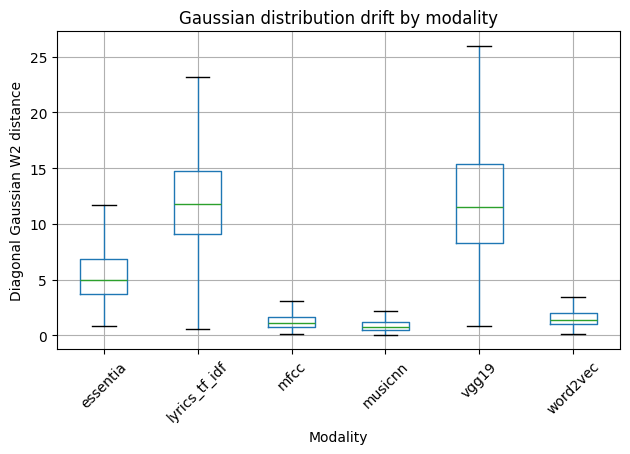

In [24]:
from pathlib import Path

FIGURE_DIR = Path("../outputs/figures/RQ1")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))

gaussian.boxplot(
    column="w2_distance",
    by="modality",
    rot=45,
    showfliers=False
)

plt.title("Gaussian distribution drift by modality")
plt.suptitle("")
plt.xlabel("Modality")
plt.ylabel("Diagonal Gaussian W2 distance")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_gaussian_w2_drift_boxplot_by_modality_no_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_gaussian_w2_drift_boxplot_by_modality_no_outliers.pdf",
    bbox_inches="tight"
)

plt.show()

In [25]:
component_summary = (
    gaussian
    .groupby("modality")[["w2_distance", "mean_component", "std_component"]]
    .agg(["count", "mean", "median", "std"])
)

component_summary

w2_distance                                 mean_component  \
                    count       mean     median       std          count   
modality                                                                   
essentia             2515   6.084773   4.942005  5.213534           2515   
lyrics_tf_idf        2515  11.962482  11.829493  4.202436           2515   
mfcc                 2515   1.399564   1.106506  1.107577           2515   
musicnn              2515   0.989933   0.796258  0.733379           2515   
vgg19                2338  12.444504  11.502626  6.170147           2338   
word2vec             2515   1.569341   1.421017  0.828246           2515   

                                            std_component             \
                   mean    median       std         count       mean   
modality                                                               
essentia       2.243250  2.015251  1.270037          2515   5.568252   
lyrics_tf_idf  2.095477  2.015680  1.004044          2515  11.769251   
mfcc           0.700248  0.612343  0.405461          2515   1.179446   
musicnn        0.481418  0.402974  0.336137          2515   0.840693   
vgg19          7.515537  6.771687  4.092967          2338   9.845242   
word2vec       1.201137  1.097865  0.644722          2515   0.985943   

                                    
                  median       std  
modality                            
essentia        4.412625  5.153174  
lyrics_tf_idf  11.663931  4.104525  
mfcc            0.877180  1.067566  
musicnn         0.644154  0.682871  
vgg19           9.159245  4.772058  
word2vec        0.872289  0.564236

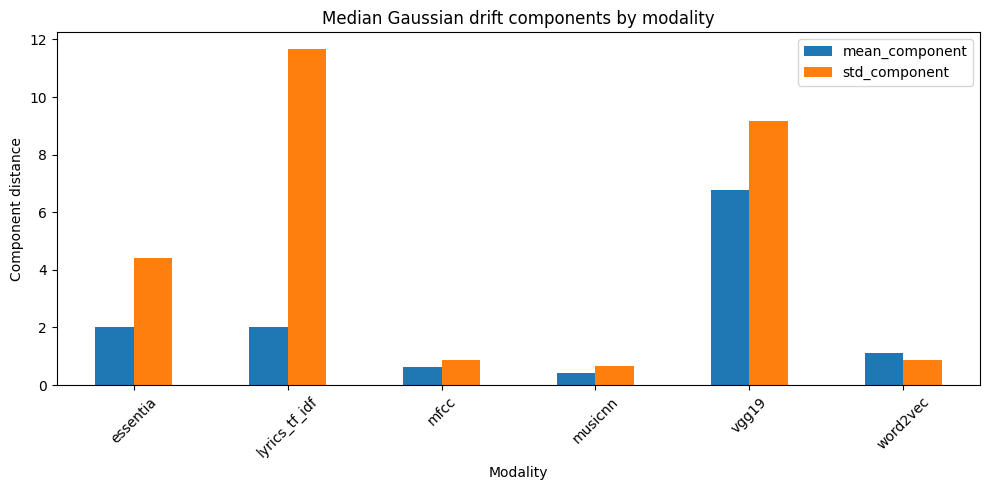

In [26]:
component_plot = (
    gaussian
    .groupby("modality")[["mean_component", "std_component"]]
    .median()
    .reset_index()
)

component_plot.plot(
    x="modality",
    y=["mean_component", "std_component"],
    kind="bar",
    figsize=(10, 5),
    rot=45
)

plt.title("Median Gaussian drift components by modality")
plt.xlabel("Modality")
plt.ylabel("Component distance")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rq1_gaussian_w2_components_by_modality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "rq1_gaussian_w2_components_by_modality.pdf",
    bbox_inches="tight"
)

plt.show()

In [27]:
centroid_summary = (
    centroid
    .groupby("modality")["cosine_distance"]
    .agg(
        centroid_count="count",
        centroid_mean="mean",
        centroid_median="median"
    )
    .reset_index()
)

gaussian_summary = (
    gaussian
    .groupby("modality")["w2_distance"]
    .agg(
        gaussian_count="count",
        gaussian_mean="mean",
        gaussian_median="median"
    )
    .reset_index()
)

comparison = centroid_summary.merge(
    gaussian_summary,
    on="modality",
    how="inner"
)

comparison["centroid_rank"] = comparison["centroid_median"].rank(
    ascending=False,
    method="min"
)

comparison["gaussian_rank"] = comparison["gaussian_median"].rank(
    ascending=False,
    method="min"
)

comparison = comparison.sort_values("centroid_rank")

comparison

,modality,centroid_count,centroid_mean,centroid_median,gaussian_count,gaussian_mean,gaussian_median,centroid_rank,gaussian_rank
1,lyrics_tf_idf,3076,0.131162,0.117742,2515,11.962482,11.829493,1.0,1.0
4,vgg19,2888,0.098772,0.072895,2338,12.444504,11.502626,2.0,2.0
5,word2vec,3076,0.057076,0.033075,2515,1.569341,1.421017,3.0,4.0
0,essentia,3076,0.048244,0.028557,2515,6.084773,4.942005,4.0,3.0
2,mfcc,3076,0.048986,0.026090,2515,1.399564,1.106506,5.0,5.0
3,musicnn,3076,0.019336,0.007909,2515,0.989933,0.796258,6.0,6.0


### Interpretation

The comparison shows that the centroid-based and Gaussian distribution-based analyses lead to broadly similar modality-level conclusions. Lyrics TF-IDF has the highest temporal drift in both representations, and VGG19 is ranked second in both cases. This supports the interpretation that lyric-term features and visual cover-art features show the strongest temporal genre movement among the analyzed modalities.

MusicNN is ranked lowest in both analyses. This suggests that MusicNN genre representations are comparatively stable over neighboring temporal windows, both when using centroid movement and when modeling genre-windows as Gaussian distributions.

The main difference appears between Word2Vec and Essentia. Word2Vec has the third-highest centroid drift, but drops to fourth place in the Gaussian distribution-based ranking. Essentia shows the opposite pattern: it is only ranked fourth in centroid drift, but rises to third place in Gaussian distribution drift. This suggests that Essentia may involve more distributional change than centroid-only movement indicates, possibly because the within-genre spread changes over time.

The absolute values of centroid cosine distance and Gaussian W2 distance should not be compared directly because they are different distance measures. The meaningful comparison here is the relative modality ranking. Overall, the Gaussian distribution-based analysis mostly supports the centroid-based findings, while refining the interpretation for Essentia and Word2Vec.